# 淘宝用户行为数据分析 - 异常波动监控

## 1. 加载数据

本Notebook用于检测用户行为数据中的异常波动，识别异常事件。

In [3]:
import sys
sys.path.append('../src')

import numpy as np

from data_loader import load_cleaned_data
from metrics import calculate_daily_metrics, calculate_hourly_metrics
from plot_utils import plot_z_score_anomalies,plot_ma_anomalies

df = load_cleaned_data()
print(f'本次共加载{len(df)}条数据')

本次共加载9039480条数据


## 2. 计算指标

In [4]:
daily_metrics = calculate_daily_metrics(df)

## 3.基于Z-score的异常检测

In [5]:
def detect_anomaly_zscore(data, threshold=3):
    mean = data.mean()
    std = data.std()
    Z_score = (data - mean) / std
    anomalies = np.abs(Z_score) > threshold
    return anomalies,Z_score

daily_metrics['pv_anomalies'],daily_metrics['pv_Z_score'] = detect_anomaly_zscore(daily_metrics['pv'], threshold=3)
daily_metrics['purchase_anomalies'],daily_metrics['purchase_Z_score'] = detect_anomaly_zscore(daily_metrics['purchase'], threshold=3)

print(f'浏览异常天数：{daily_metrics['pv_anomalies'].sum()}')
display(daily_metrics[daily_metrics['pv_anomalies']][['date','pv','pv_Z_score']])

print(f'购买异常天数：{daily_metrics['purchase_anomalies'].sum()}')
display(daily_metrics[daily_metrics['purchase_anomalies']][['date','purchase','purchase_Z_score']])

浏览异常天数：1


,date,pv,pv_Z_score
24,2014-12-12,527970,4.242281


购买异常天数：1


,date,purchase,purchase_Z_score
24,2014-12-12,14745,5.318811


## 4.异常可视化

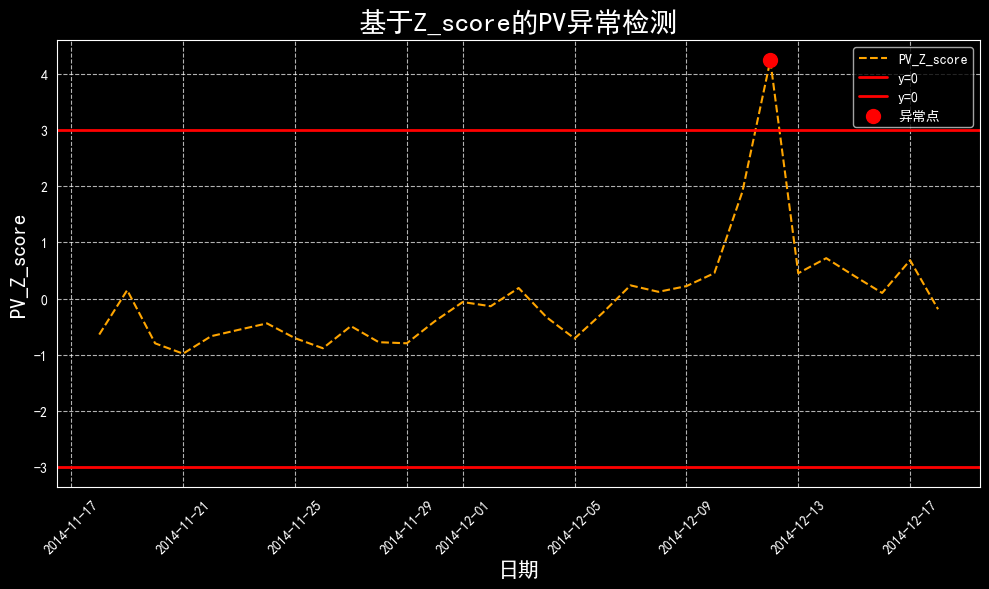

In [6]:
plot_z_score_anomalies(daily_metrics)

## 5.基于移动平均的异常检测

In [7]:
window_size = 3
daily_metrics['pv_ma'] = daily_metrics['pv'].rolling(window=window_size).mean()
daily_metrics['pv_std'] = daily_metrics['pv'].rolling(window=window_size).std()
daily_metrics['pv_upper'] = daily_metrics['pv_ma'] + 2 * daily_metrics['pv_std']
daily_metrics['pv_lower'] = daily_metrics['pv_ma'] - 2 * daily_metrics['pv_std']

daily_metrics['pv_anomaly_ma'] = (daily_metrics['pv'] > daily_metrics['pv_upper']) | (daily_metrics['pv'] < daily_metrics['pv_lower'])

print(f"异常天数: {daily_metrics['pv_anomaly_ma'].sum()}")
display(daily_metrics[daily_metrics['pv_anomaly_ma']][['date', 'pv', 'pv_ma', 'pv_upper', 'pv_lower']])

异常天数: 0


,date,pv,pv_ma,pv_upper,pv_lower


## 6.异常可视化

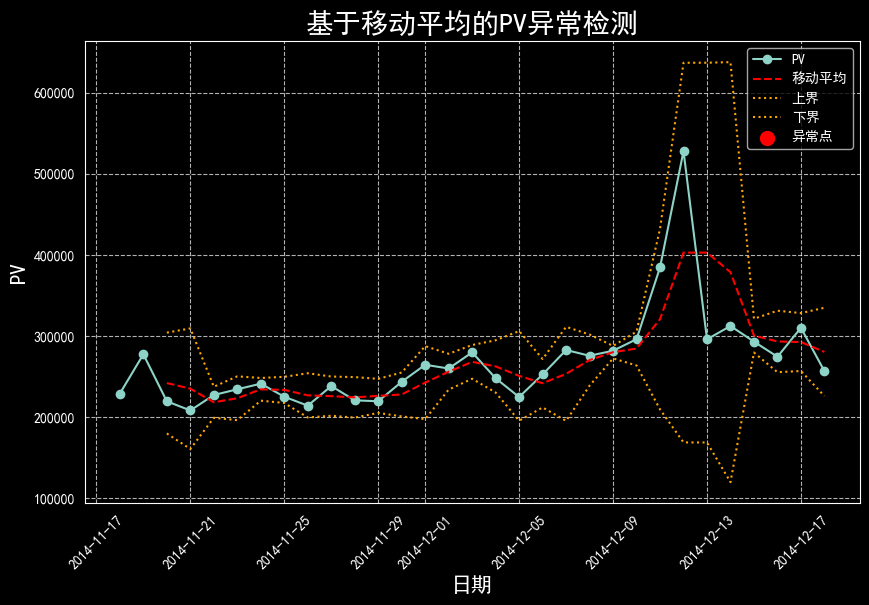

In [9]:
plot_ma_anomalies(daily_metrics)